# EDA 03 - Train Movements

**Output**: `data/processed/train_moments_clean.parquet`, `data/processed/train_station_day.parquet`

This notebook prepares TRUST train movement records before exploratory analysis. The workflow is raw load, timestamp and station checks, SMART-first duplicate handling, delay feature derivation, Parquet save and then EDA on the cleaned movement records.

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_03", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./sample_data/processed", exist_ok=True)
%matplotlib inline

## 1. Load and Inspect Raw Data

In [2]:
from datetime import datetime, timezone
from src.data_loader import load_train_moment_files, parse_train_moments

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 28, 23, 59, 59, tzinfo=timezone.utc)

stations_reference_df = pd.read_parquet("./data/processed/stations_reference.parquet")

train_files = load_train_moment_files(START, END)
print(f"Files retrieved: {len(train_files)}")

raw_df = parse_train_moments(train_files, stations_reference_df)
print(f"Raw shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")

Using 2596 local files within the time window.
Files retrieved: 2596
Skipping empty CSV file: data\train\train_data_20260426_151255.csv
Raw shape: (296940, 20)
Columns: ['train_id', 'actual_timestamp', 'planned_timestamp', 'gbtt_timestamp', 'loc_stanox', 'next_stanox', 'event_type', 'planned_event_type', 'variation_status', 'timetable_variation', 'platform', 'route', 'direction', 'train_terminated', 'delay_monitoring_point', 'msg_timestamp', 'data_source', 'is_delayed', 'station_code', 'station_name']


## 2. Data preprocessing, deduplication, feature derivation and Parquet save

The movement key is `train_id`, `loc_stanox`, `actual_timestamp` and `event_type`. The known duplicate pattern is not a repeated file row. It is a dual-source report where SMART and GPS describe the same physical train event. SMART is retained because it carries richer timetable variation information.

In [3]:
# Keep rows that can support delay calculation.
before = len(raw_df)
clean_df = raw_df.dropna(subset=["actual_timestamp", "planned_timestamp"]).copy()
print(f"Dropped {before - len(clean_df):,} rows with missing timestamps")

# Station name is needed for station-level aggregation.
before = len(clean_df)
clean_df = clean_df.dropna(subset=["station_name"]).copy()
print(f"Dropped {before - len(clean_df):,} rows with missing station name")

# SMART is preferred when SMART and GPS report the same train event.
source_priority = {"SMART": 0, "GPS": 1}
clean_df["_source_priority"] = (
    clean_df["data_source"].map(source_priority).fillna(9)
    if "data_source" in clean_df.columns else 9
)
movement_key = [c for c in ["train_id", "loc_stanox", "actual_timestamp", "event_type"] if c in clean_df.columns]
sort_cols = ["_source_priority"] + [c for c in ["msg_timestamp"] if c in clean_df.columns]
before = len(clean_df)
clean_df = (
    clean_df
    .sort_values(sort_cols)
    .drop_duplicates(subset=movement_key, keep="first")
    .copy()
)
print(f"Duplicate movement events removed: {before - len(clean_df):,}")
clean_df = clean_df.drop(columns=["_source_priority"])

# Convert platform and route to string for better access in data
for col in ["platform", "route"]:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].astype("string")



Dropped 16,122 rows with missing timestamps
Dropped 67,934 rows with missing station name
Duplicate movement events removed: 239


### 2a.Compute Delay Features

In [4]:
# Delay features are derived once and reused in later EDA cells.
clean_df["planned_date"] = clean_df["planned_timestamp"].dt.date
clean_df["actual_date"] = clean_df["actual_timestamp"].dt.date
clean_df["delay_minutes_raw"] = (
    clean_df["actual_timestamp"] - clean_df["planned_timestamp"]
).dt.total_seconds() / 60

# Cap delay minutes to 1st and 99th percentiles to reduce outlier impact on station-day aggregation.
P01 = clean_df["delay_minutes_raw"].quantile(0.01)
P99 = clean_df["delay_minutes_raw"].quantile(0.99)
clean_df["delay_minutes"] = clean_df["delay_minutes_raw"].clip(lower=P01, upper=P99)

clean_df["late_minutes"] = clean_df["delay_minutes"].clip(lower=0)
clean_df["early_minutes"] = (-clean_df["delay_minutes"]).clip(lower=0)
clean_df["is_late"] = (clean_df["delay_minutes"] > 0).astype(int)
clean_df["is_early"] = (clean_df["delay_minutes"] < 0).astype(int)
clean_df["is_delayed_5min"] = (clean_df["delay_minutes"] > 5).astype(int)
clean_df["is_severely_delayed_15min"] = (clean_df["delay_minutes"] > 15).astype(int)
clean_df["actual_hour"] = clean_df["actual_timestamp"].dt.hour
clean_df["actual_dow"] = clean_df["actual_timestamp"].dt.dayofweek
clean_df["is_peak"] = clean_df["actual_hour"].isin(list(range(7, 10)) + list(range(17, 20))).astype(int)

display(clean_df.head())

,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,station_code,station_name,planned_date,actual_date,delay_minutes_raw,delay_minutes,late_minutes,early_minutes,is_late,is_early,is_delayed_5min,is_severely_delayed_15min,actual_hour,actual_dow,is_peak
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1775810813000,SMART,0,RYH,Rye House,2026-04-10,2026-04-10,-0.5,-0.5,0.0,0.5,0,1,0,0,9,4,1
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1775810814000,SMART,0,BMD,Brimsdown,2026-04-10,2026-04-10,0.0,0.0,0.0,-0.0,0,0,0,0,9,4,1
4,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1775810814000,SMART,1,WST,Wood Street,2026-04-10,2026-04-10,0.5,0.5,0.5,0.0,1,0,0,0,9,4,1
10,062E62MD10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,6714.0,7331.0,ARRIVAL,ARRIVAL,LATE,1.0,2,0.0,UP,False,False,1775810815000,SMART,1,BAI,Blairhill,2026-04-10,2026-04-10,0.5,0.5,0.5,0.0,1,0,0,0,9,4,1
11,322A95MF10,2026-04-10 09:48:00,2026-04-10 09:46:30,2026-04-10 09:47:00,32524.0,32526.0,ARRIVAL,ARRIVAL,LATE,2.0,2,0.0,UP,False,False,1775810815000,SMART,1,EDY,East Didsbury,2026-04-10,2026-04-10,1.5,1.5,1.5,0.0,1,0,0,0,9,4,1


In [5]:
def aggregate_station_day(df, group_cols=None):
    """Create the station-day modelling table from movement-level records."""
    if group_cols is None:
        group_cols = ["station_name", "loc_stanox", "planned_date"]
    agg = (df.groupby(group_cols).agg(
        train_movements=("train_id", "count"),
        mean_delay_minutes=("delay_minutes", "mean"),
        median_delay_minutes=("delay_minutes", "median"),
        max_delay_minutes=("delay_minutes", "max"),
        late_share=("is_late", "mean"),
        delayed_5min_share=("is_delayed_5min", "mean"),
        severe_15min_share=("is_severely_delayed_15min", "mean"),
        peak_movement_share=("is_peak", "mean"),
    ).reset_index())
    agg["station_disrupted"] = (agg["mean_delay_minutes"] > 5).astype(int)
    return agg

train_station_day = aggregate_station_day(clean_df)
display(train_station_day.head())

,station_name,loc_stanox,planned_date,train_movements,mean_delay_minutes,median_delay_minutes,max_delay_minutes,late_share,delayed_5min_share,severe_15min_share,peak_movement_share,station_disrupted
0,Abbey Wood,88601.0,2026-04-10,15,0.566667,-0.50,12.0,0.333333,0.066667,0.0,0.066667,0
1,Abbey Wood,88601.0,2026-04-11,2,-0.750000,-0.75,-0.5,0.000000,0.000000,0.0,0.500000,0
2,Abbey Wood,88601.0,2026-04-12,4,1.000000,0.50,3.5,0.750000,0.000000,0.0,0.500000,0
3,Abbey Wood,88601.0,2026-04-13,14,0.535714,0.00,6.0,0.214286,0.071429,0.0,0.428571,0
4,Abbey Wood,88601.0,2026-04-14,6,0.666667,-0.25,4.5,0.333333,0.000000,0.0,0.666667,0


### Save train movements data aggregated by station for each day

In [6]:

clean_df.to_parquet("./data/processed/train_moments_clean.parquet", index=False)
train_station_day.to_parquet("./data/processed/train_station_day.parquet", index=False)
clean_df.to_csv("./sample_data/processed/train_moments_clean.csv", index=False)
train_station_day.to_csv("./sample_data/processed/train_station_day.csv", index=False)

print(f"Clean movement rows saved: {len(clean_df):,}")
print(f"Station-day rows saved:    {len(train_station_day):,}")
print(f"Deduplication key:         {movement_key}")
print(f"Winsorised delay range:    [{P01:.1f}, {P99:.1f}] minutes")

Clean movement rows saved: 212,645
Station-day rows saved:    33,941
Deduplication key:         ['train_id', 'loc_stanox', 'actual_timestamp', 'event_type']
Winsorised delay range:    [-8.0, 22.5] minutes


In [7]:
print("Train Movements Earlier Planned Time:", clean_df['planned_timestamp'].min())
print("Train Movements Latest Planned Time:", clean_df['planned_timestamp'].max())

print("Station-Day Time Range:", train_station_day["planned_date"].min(), "to", train_station_day["planned_date"].max())

Train Movements Earlier Planned Time: 2026-04-03 23:56:00
Train Movements Latest Planned Time: 2026-04-28 17:46:30
Station-Day Time Range: 2026-04-03 to 2026-04-28


### Cleaned data types and basic statistics

The remaining summaries use `clean_df`, which has already passed the timestamp, station and duplicate checks.

In [8]:
display(clean_df.head())
clean_df.info()
display(clean_df.describe().round(2))


,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,station_code,station_name,planned_date,actual_date,delay_minutes_raw,delay_minutes,late_minutes,early_minutes,is_late,is_early,is_delayed_5min,is_severely_delayed_15min,actual_hour,actual_dow,is_peak
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1775810813000,SMART,0,RYH,Rye House,2026-04-10,2026-04-10,-0.5,-0.5,0.0,0.5,0,1,0,0,9,4,1
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1775810814000,SMART,0,BMD,Brimsdown,2026-04-10,2026-04-10,0.0,0.0,0.0,-0.0,0,0,0,0,9,4,1
4,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1775810814000,SMART,1,WST,Wood Street,2026-04-10,2026-04-10,0.5,0.5,0.5,0.0,1,0,0,0,9,4,1
10,062E62MD10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,6714.0,7331.0,ARRIVAL,ARRIVAL,LATE,1.0,2,0.0,UP,False,False,1775810815000,SMART,1,BAI,Blairhill,2026-04-10,2026-04-10,0.5,0.5,0.5,0.0,1,0,0,0,9,4,1
11,322A95MF10,2026-04-10 09:48:00,2026-04-10 09:46:30,2026-04-10 09:47:00,32524.0,32526.0,ARRIVAL,ARRIVAL,LATE,2.0,2,0.0,UP,False,False,1775810815000,SMART,1,EDY,East Didsbury,2026-04-10,2026-04-10,1.5,1.5,1.5,0.0,1,0,0,0,9,4,1


<class 'pandas.DataFrame'>
Index: 212645 entries, 1 to 296923
Data columns (total 33 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   train_id                   212645 non-null  str           
 1   actual_timestamp           212645 non-null  datetime64[ms]
 2   planned_timestamp          212645 non-null  datetime64[ms]
 3   gbtt_timestamp             177073 non-null  datetime64[ms]
 4   loc_stanox                 212645 non-null  float64       
 5   next_stanox                202897 non-null  float64       
 6   event_type                 212645 non-null  str           
 7   planned_event_type         212645 non-null  str           
 8   variation_status           212645 non-null  str           
 9   timetable_variation        212645 non-null  float64       
 10  platform                   175587 non-null  string        
 11  route                      204035 non-null  string        
 12  dire

,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,timetable_variation,msg_timestamp,is_delayed,delay_minutes_raw,delay_minutes,late_minutes,early_minutes,is_late,is_early,is_delayed_5min,is_severely_delayed_15min,actual_hour,actual_dow,is_peak
count,212645,212645,177073,212645.00,202897.00,212645.00,2.126450e+05,212645.00,212645.00,212645.00,212645.00,212645.00,212645.00,212645.00,212645.00,212645.00,212645.00,212645.00,212645.00
mean,2026-04-20 12:10:20.517000,2026-04-20 12:09:17.323000,2026-04-20 11:57:22.229000,59101.62,59250.85,2.31,1.776684e+12,0.42,1.05,1.00,1.49,0.49,0.42,0.39,0.08,0.02,13.19,2.68,0.38
min,2026-04-03 23:44:00,2026-04-03 23:56:00,2026-04-03 23:56:00,1001.00,1001.00,0.00,1.775811e+12,0.00,-295.00,-8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2026-04-15 08:41:00,2026-04-15 08:40:00,2026-04-15 08:38:00,38184.00,38185.00,0.00,1.776239e+12,0.00,-0.50,-0.50,0.00,0.00,0.00,0.00,0.00,0.00,9.00,1.00,0.00
50%,2026-04-21 06:52:00,2026-04-21 06:51:30,2026-04-21 06:44:00,65811.00,65823.00,1.00,1.776751e+12,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,13.00,3.00,0.00
75%,2026-04-26 13:05:00,2026-04-26 13:03:00,2026-04-26 13:05:00,87114.00,87133.00,2.00,1.777205e+12,1.00,1.50,1.50,1.50,0.50,1.00,1.00,0.00,0.00,18.00,4.00,1.00
max,2026-04-28 17:46:00,2026-04-28 17:46:30,2026-04-28 17:47:00,89743.00,89743.00,458.00,1.777394e+12,1.00,457.50,22.50,22.50,8.00,1.00,1.00,1.00,1.00,23.00,6.00,1.00
std,NaN,NaN,NaN,27682.00,27607.45,6.56,5.078154e+08,0.49,6.83,3.86,3.51,1.08,0.49,0.49,0.27,0.14,5.48,2.13,0.49


## 3. Missing value audit

This audit is run after cleaning. It checks residual missingness in descriptive fields rather than fields already required for delay calculation and station matching.

In [9]:
missing = pd.DataFrame({
    "missing_count": clean_df.isna().sum(),
    "missing_pct": (clean_df.isna().sum() / len(clean_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())
print()
for col in ["actual_timestamp", "planned_timestamp", "station_name"]:
    n = clean_df[col].isna().sum()
    print(f"{col} missing after cleaning: {n:,}")

                           missing_count  missing_pct
platform                           37058        17.43
gbtt_timestamp                     35572        16.73
direction                          30748        14.46
next_stanox                         9748         4.58
route                               8610         4.05
train_id                               0         0.00
loc_stanox                             0         0.00
planned_timestamp                      0         0.00
actual_timestamp                       0         0.00
variation_status                       0         0.00
planned_event_type                     0         0.00
event_type                             0         0.00
timetable_variation                    0         0.00
train_terminated                       0         0.00
delay_monitoring_point                 0         0.00
msg_timestamp                          0         0.00
data_source                            0         0.00
is_delayed                  

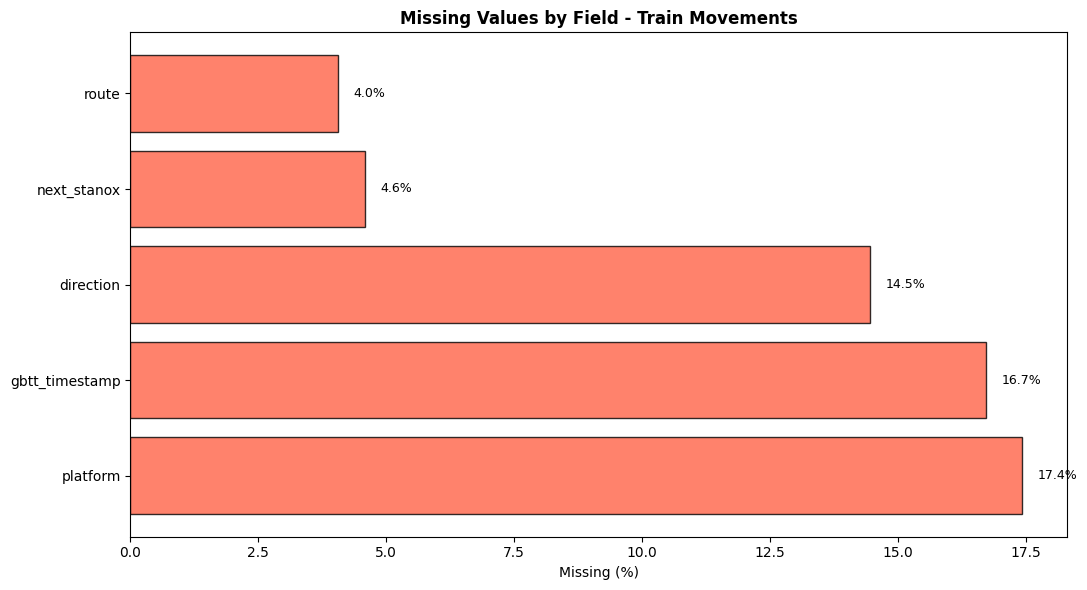

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
missing_nonzero = missing[missing["missing_pct"] > 0]

if len(missing_nonzero) > 0:
    ax.barh(missing_nonzero.index, missing_nonzero["missing_pct"],
            color="tomato", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    for i, v in enumerate(missing_nonzero["missing_pct"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)

ax.set_title("Missing Values by Field - Train Movements", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_03/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Compute Delay Features

All delay features are derived from `actual_timestamp - planned_timestamp`. The `delay_minutes` column is winsorised at the 1st/99th percentile at the end of section 4 before station-day aggregation, so individual extreme trains do not skew station-level means.

In [11]:
print("Delay statistics after preprocessing and winsorisation (minutes):")
print(clean_df["delay_minutes"].describe().round(2))
print(f"\nLate movements (any delay):    {clean_df['is_late'].sum():,} ({clean_df['is_late'].mean() * 100:.1f}%)")
print(f"Early movements:               {clean_df['is_early'].sum():,} ({clean_df['is_early'].mean() * 100:.1f}%)")
print(f"Delayed > 5 min (industry):    {clean_df['is_delayed_5min'].sum():,} ({clean_df['is_delayed_5min'].mean() * 100:.1f}%)")
print(f"Severely delayed > 15 min:     {clean_df['is_severely_delayed_15min'].sum():,} ({clean_df['is_severely_delayed_15min'].mean() * 100:.1f}%)")


Delay statistics after preprocessing and winsorisation (minutes):
count    212645.00
mean          1.00
std           3.86
min          -8.00
25%          -0.50
50%           0.00
75%           1.50
max          22.50
Name: delay_minutes, dtype: float64

Late movements (any delay):    88,773 (41.7%)
Early movements:               82,745 (38.9%)
Delayed > 5 min (industry):    16,532 (7.8%)
Severely delayed > 15 min:     4,130 (1.9%)


## 5. Delay Distribution

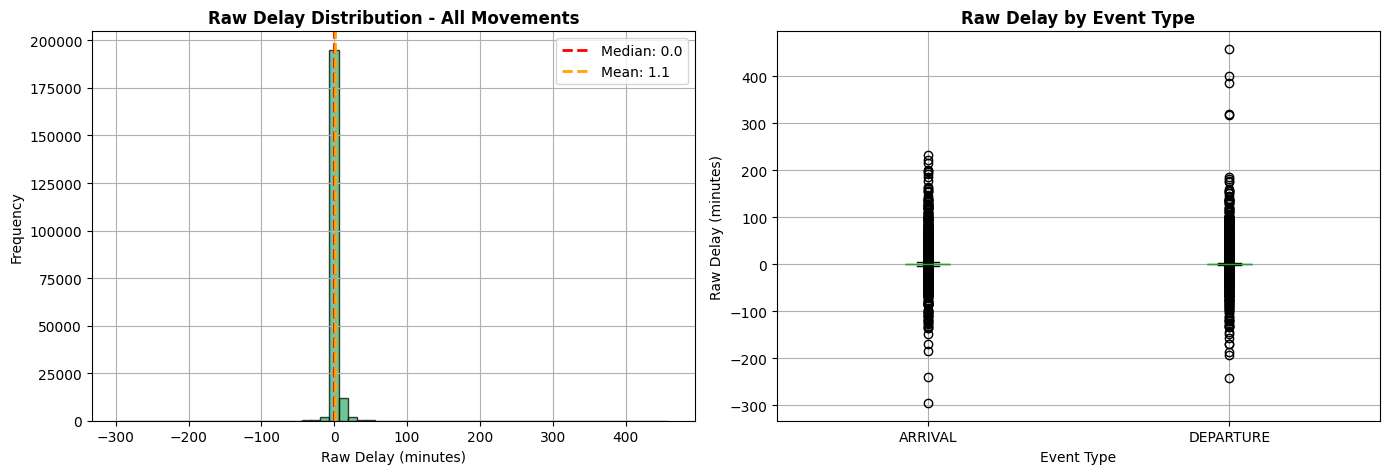


Quantiles:
0.01    -8.0
0.05    -2.0
0.25    -0.5
0.50     0.0
0.75     1.5
0.95     7.5
0.99    22.5
Name: delay_minutes_raw, dtype: float64

Skewness: 7.213   Kurtosis: 421.947


In [12]:
delay = clean_df["delay_minutes_raw"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=60, ax=axes[0], edgecolor="black", alpha=0.75, color="mediumseagreen")
axes[0].axvline(delay.median(), color="red",    linestyle="--", lw=2,
                label=f"Median: {delay.median():.1f}")
axes[0].axvline(delay.mean(),   color="orange", linestyle="--", lw=2,
                label=f"Mean: {delay.mean():.1f}")
axes[0].set_xlabel("Raw Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Raw Delay Distribution - All Movements", fontweight="bold")
axes[0].legend()

clean_df.boxplot(column="delay_minutes_raw", by="event_type", ax=axes[1], patch_artist=True)
axes[1].set_title("Raw Delay by Event Type", fontweight="bold")
axes[1].set_xlabel("Event Type")
axes[1].set_ylabel("Raw Delay (minutes)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("figures/eda_03/raw_delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nQuantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))
print(f"\nSkewness: {delay.skew():.3f}   Kurtosis: {delay.kurtosis():.3f}")

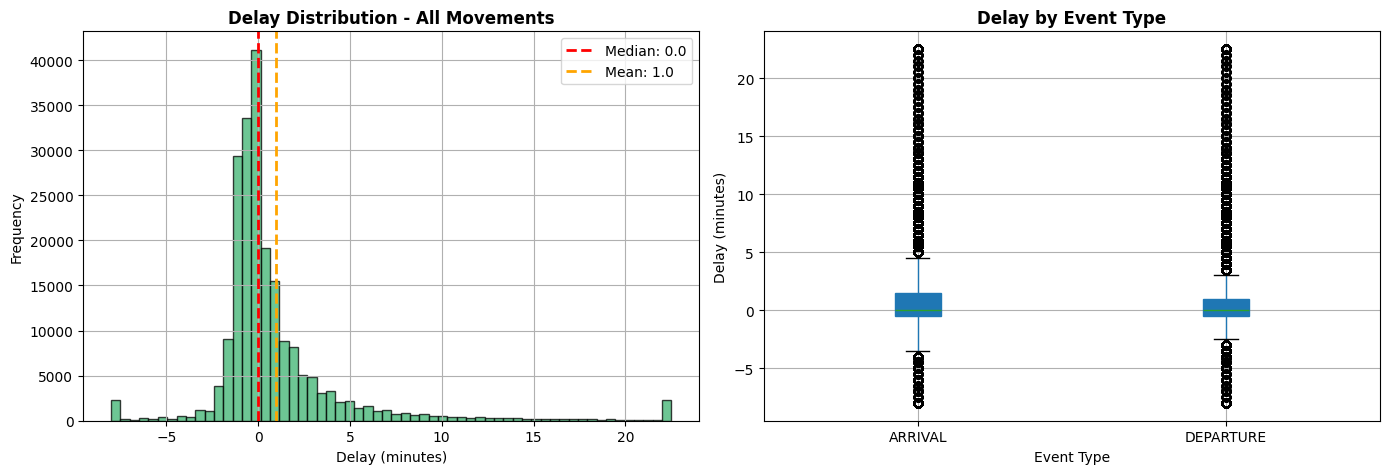


Quantiles:
0.01    -8.0
0.05    -2.0
0.25    -0.5
0.50     0.0
0.75     1.5
0.95     7.5
0.99    22.5
Name: delay_minutes, dtype: float64

Skewness: 3.018   Kurtosis: 12.854


In [13]:
delay = clean_df["delay_minutes"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=60, ax=axes[0], edgecolor="black", alpha=0.75, color="mediumseagreen")
axes[0].axvline(delay.median(), color="red",    linestyle="--", lw=2,
                label=f"Median: {delay.median():.1f}")
axes[0].axvline(delay.mean(),   color="orange", linestyle="--", lw=2,
                label=f"Mean: {delay.mean():.1f}")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Delay Distribution - All Movements", fontweight="bold")
axes[0].legend()

clean_df.boxplot(column="delay_minutes", by="event_type", ax=axes[1], patch_artist=True)
axes[1].set_title("Delay by Event Type", fontweight="bold")
axes[1].set_xlabel("Event Type")
axes[1].set_ylabel("Delay (minutes)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("figures/eda_03/delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nQuantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))
print(f"\nSkewness: {delay.skew():.3f}   Kurtosis: {delay.kurtosis():.3f}")

## 6. Delay by Peak vs Off-Peak

Peak hours (07:00-09:00 and 17:00-19:00) are defined consistently with the `is_peak` feature computed in section 2a and used in the station-day aggregation.

Delay by peak vs off-peak:


,count,mean,median,std
is_peak,,,,
Off-peak,130970,0.942,0.0,3.990
"Peak (07-09, 17-19)",81675,1.099,0.0,3.641


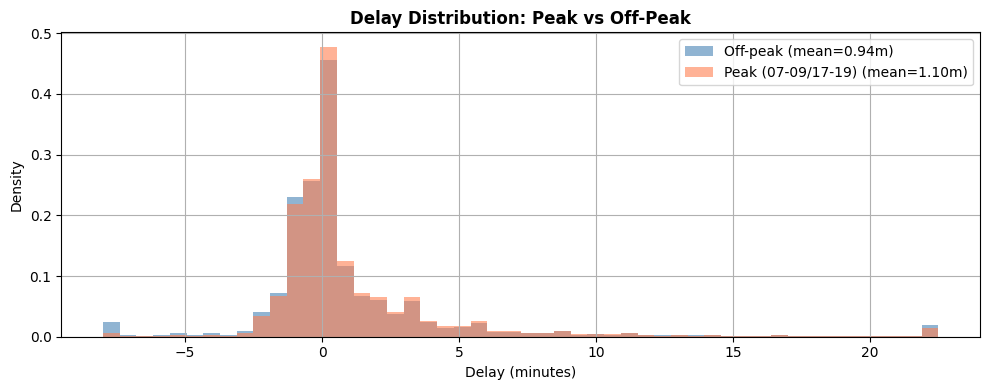

In [14]:
peak_summary = (
    clean_df
    .groupby("is_peak")["delay_minutes"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
    .rename(index={0: "Off-peak", 1: "Peak (07-09, 17-19)"})
)
print("Delay by peak vs off-peak:")
display(peak_summary)

fig, ax = plt.subplots(figsize=(10, 4))
for label, grp, color in [
    ("Off-peak",          clean_df[clean_df["is_peak"] == 0]["delay_minutes"], "steelblue"),
    ("Peak (07-09/17-19)", clean_df[clean_df["is_peak"] == 1]["delay_minutes"], "coral"),
]:
    grp.hist(bins=50, ax=ax, alpha=0.6, color=color,
             label=f"{label} (mean={grp.mean():.2f}m)", density=True)

ax.set_xlabel("Delay (minutes)")
ax.set_ylabel("Density")
ax.set_title("Delay Distribution: Peak vs Off-Peak", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("figures/eda_03/delay_peak_vs_offpeak.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Event Type and Variation Status

`event_type` distinguishes arrivals, departures and passes. `variation_status` is the TRUST operational flag (EARLY, ON TIME, LATE). The cross-tabulation confirms alignment between the computed delay sign and the TRUST-reported status.

In [15]:
et = clean_df["event_type"].value_counts()
vs = clean_df["variation_status"].value_counts()

print("=== Event Type ===")
print(et.to_string())
print()
print("=== Variation Status ===")
print(vs.to_string())
print()
print("=== Cross-tabulation: Event Type × Variation Status ===")
print(pd.crosstab(clean_df["event_type"], clean_df["variation_status"],
                  margins=True).to_string())

=== Event Type ===
event_type
DEPARTURE    108258
ARRIVAL      104387

=== Variation Status ===
variation_status
LATE       88773
ON TIME    74653
EARLY      49219

=== Cross-tabulation: Event Type × Variation Status ===
variation_status  EARLY   LATE  ON TIME     All
event_type                                     
ARRIVAL           24445  45303    34639  104387
DEPARTURE         24774  43470    40014  108258
All               49219  88773    74653  212645


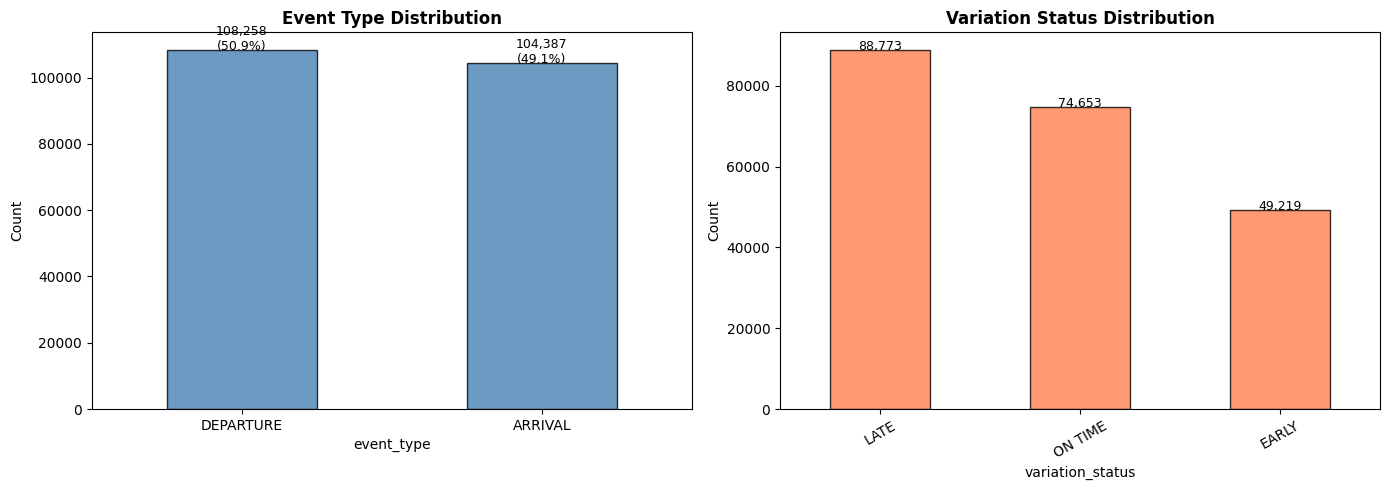

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

et.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Event Type Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(clean_df)*100:.1f}%)",
                 ha="center", fontsize=9)

vs.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Variation Status Distribution", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(vs.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_03/event_variation.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Temporal Distribution of Movements

Peak hours are shaded in the hour-of-day chart to show how movement volume relates to the peak definition used in section 3.

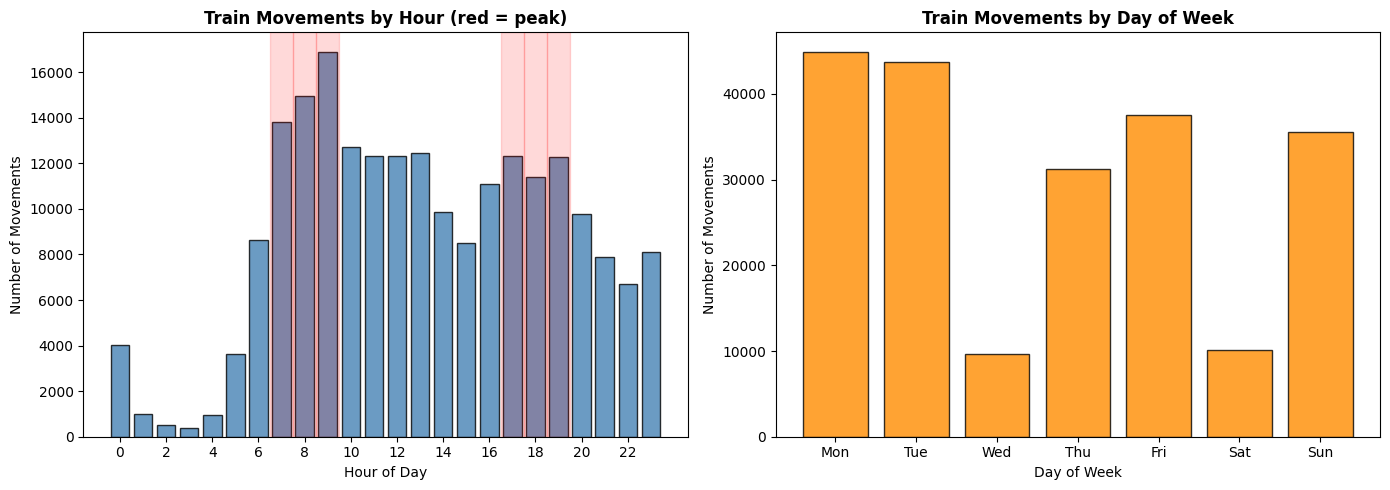

Movements by date:
actual_date
2026-04-03        1
2026-04-08        1
2026-04-09       42
2026-04-10    17745
2026-04-11     3498
2026-04-12     8235
2026-04-13    15252
2026-04-14     5312
2026-04-15     9597
2026-04-16    11268
2026-04-17     6993
2026-04-18     5265
2026-04-19    11852
2026-04-20     8587
2026-04-21    18313
2026-04-22        6
2026-04-23    19913
2026-04-24    12791
2026-04-25     1318
2026-04-26    15492
2026-04-27    21110
2026-04-28    20054


In [17]:
DOW_MAP = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_counts = clean_df["actual_hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color="steelblue", edgecolor="black", alpha=0.8)
# Shade peak hours
for h in list(range(7, 10)) + list(range(17, 20)):
    axes[0].axvspan(h - 0.5, h + 0.5, alpha=0.15, color="red")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Movements")
axes[0].set_title("Train Movements by Hour (red = peak)", fontweight="bold")
axes[0].set_xticks(range(0, 24, 2))

dow_counts = clean_df["actual_dow"].value_counts().sort_index()
axes[1].bar([DOW_MAP[i] for i in dow_counts.index], dow_counts.values,
            color="darkorange", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Movements")
axes[1].set_title("Train Movements by Day of Week", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_03/temporal_movements.png", dpi=200, bbox_inches="tight")
plt.show()

print("Movements by date:")
print(clean_df["actual_date"].value_counts().sort_index().to_string())

## 9. Station Code Coverage

Station codes (TLC) are mapped from STANOX via the stations reference. The match rate determines what proportion of movements can be spatially linked to road closures in EDA 05.

Total movements:           212,645
With station code matched: 212,645 (100.0%)
Without station code:      0 (0.0%)


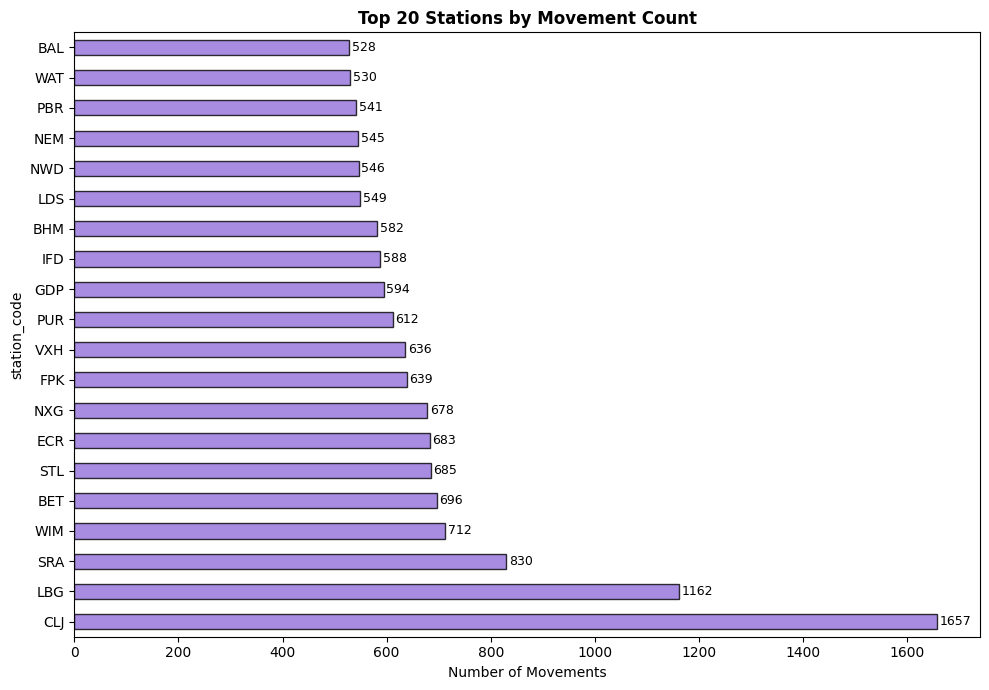

In [18]:
if "station_code" in clean_df.columns:
    matched = clean_df["station_code"].notna() & (clean_df["station_code"] != "")
    print(f"Total movements:           {len(clean_df):,}")
    print(f"With station code matched: {matched.sum():,} ({matched.mean()*100:.1f}%)")
    print(f"Without station code:      {(~matched).sum():,} ({(~matched).mean()*100:.1f}%)")

    top_stations = clean_df[matched]["station_code"].value_counts().head(20)
    plt.figure(figsize=(10, 7))
    top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Movements")
    plt.title("Top 20 Stations by Movement Count", fontweight="bold")
    for i, v in enumerate(top_stations.values):
        plt.text(v + 5, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_03/top_stations_movements.png", dpi=200, bbox_inches="tight")
    plt.show()

## 10. Operational Flags

`is_delayed` is the TRUST-derived flag; `delay_monitoring_point` marks the designated reporting location for each service; `train_terminated` flags services that ended early. These are informational and are not used as modelling features.

=== is_delayed ===
is_delayed
0    123872
1     88773
  True rate: 41.7%

=== delay_monitoring_point ===
delay_monitoring_point
True     110576
False    102069
  True rate: 52.0%

=== train_terminated ===
train_terminated
False    202897
True       9748
  True rate: 4.6%



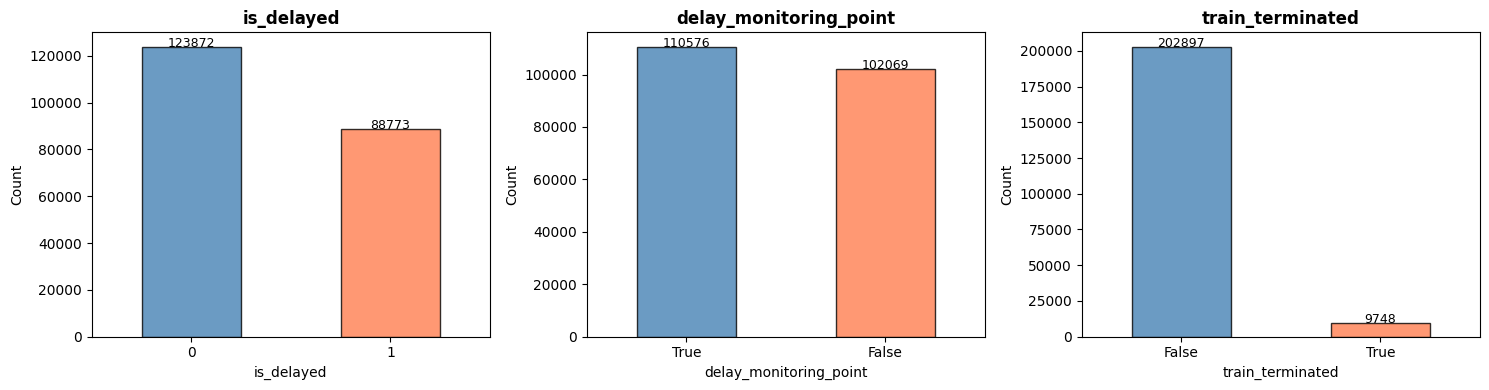

In [19]:
flag_cols = [c for c in ["is_delayed", "delay_monitoring_point", "train_terminated"]
             if c in clean_df.columns]

vc_store = {}
for col in flag_cols:
    vc = clean_df[col].value_counts(dropna=False)
    vc_store[col] = vc
    pct_true = clean_df[col].eq(True).sum() / len(clean_df) * 100
    print(f"=== {col} ===")
    print(vc.to_string())
    print(f"  True rate: {pct_true:.1f}%\n")

if flag_cols:
    fig, axes = plt.subplots(1, len(flag_cols), figsize=(5 * len(flag_cols), 4))
    if len(flag_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, flag_cols):
        vc_store[col].plot(kind="bar", ax=ax, color=["steelblue", "coral"],
                           edgecolor="black", alpha=0.8)
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)
        for i, v in enumerate(vc_store[col].values):
            ax.text(i, v + 5, str(v), ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_03/operational_flags.png", dpi=200, bbox_inches="tight")
    plt.show()

## Direction and Data Source

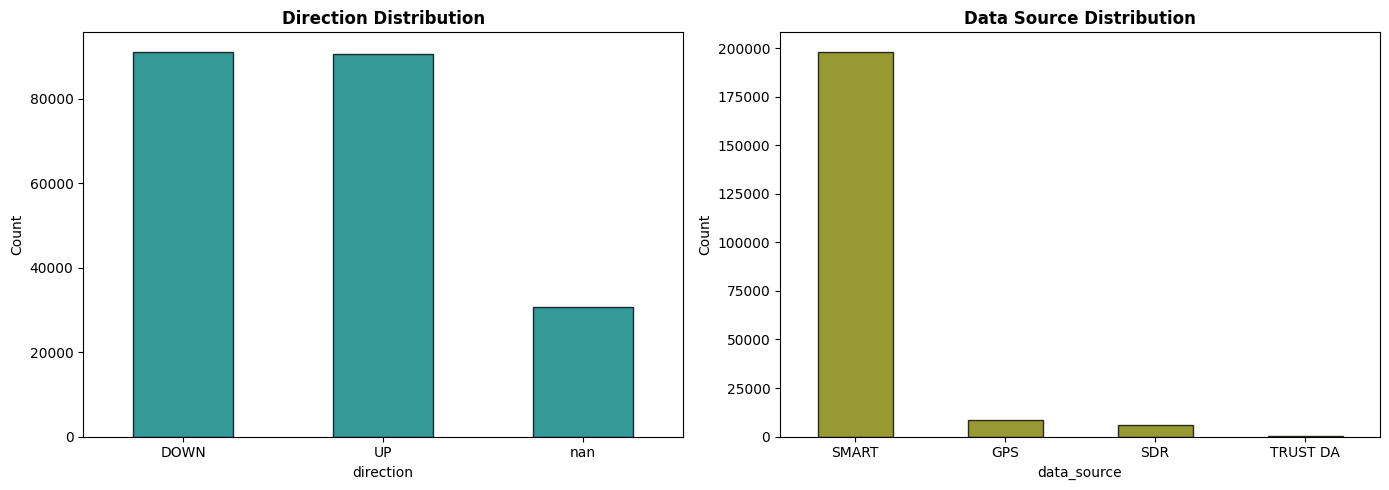

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "direction" in clean_df.columns:
    dir_counts = clean_df["direction"].value_counts(dropna=False)
    dir_counts.plot(kind="bar", ax=axes[0], color="teal",
                    edgecolor="black", alpha=0.8)
    axes[0].set_title("Direction Distribution", fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=0)

if "data_source" in clean_df.columns:
    ds_counts = clean_df["data_source"].value_counts(dropna=False)
    ds_counts.plot(kind="bar", ax=axes[1], color="olive",
                   edgecolor="black", alpha=0.8)
    axes[1].set_title("Data Source Distribution", fontweight="bold")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("figures/eda_03/direction_datasource.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Aggregate to Station-Day

Aggregate individual movement records into one row per station per day. This is the granularity used by both the classification and regression models, and the resulting columns are read directly by the Gradio UI.

### Model inputs and targets

- `train_movements`: number of movements at that station on that day
- `mean_delay_minutes`: mean signed delay - negative values indicate the station ran early
  - Used as the regression target
  - Also used to derive the binary classification label (disrupted if mean is greater than 5 minutes)
- `median_delay_minutes`: median signed delay - less sensitive to outliers and kept as a secondary performance measure

### UI display columns

Used in the historical performance table and charts:

- `late_share`: fraction of movements arriving after their planned time (percent late)
- `delayed_share_5min`: fraction delayed by more than five minutes (percent greater than 5 minutes)
- `severe_delay_share_15min`: fraction delayed by more than fifteen minutes (percent greater than 15 minutes)

### Dropped intermediate columns

- late_movements
- delayed_movements_5min
- severe_delay_movements_15min

These columns are used only to compute the share metrics and are removed before saving.


In [21]:
# train_station_day was created and saved during preprocessing.
print(f"Station-day rows: {len(train_station_day):,}")
display(train_station_day.head())
print("Station-day target distribution:")
print(train_station_day["station_disrupted"].value_counts().to_string())

Station-day rows: 33,941


,station_name,loc_stanox,planned_date,train_movements,mean_delay_minutes,median_delay_minutes,max_delay_minutes,late_share,delayed_5min_share,severe_15min_share,peak_movement_share,station_disrupted
0,Abbey Wood,88601.0,2026-04-10,15,0.566667,-0.50,12.0,0.333333,0.066667,0.0,0.066667,0
1,Abbey Wood,88601.0,2026-04-11,2,-0.750000,-0.75,-0.5,0.000000,0.000000,0.0,0.500000,0
2,Abbey Wood,88601.0,2026-04-12,4,1.000000,0.50,3.5,0.750000,0.000000,0.0,0.500000,0
3,Abbey Wood,88601.0,2026-04-13,14,0.535714,0.00,6.0,0.214286,0.071429,0.0,0.428571,0
4,Abbey Wood,88601.0,2026-04-14,6,0.666667,-0.25,4.5,0.333333,0.000000,0.0,0.666667,0


Station-day target distribution:
station_disrupted
0    32024
1     1917


In [22]:
print(f"Already saved before EDA: train_moments_clean.parquet - {len(clean_df):,} rows")
print(f"Already saved before EDA: train_station_day.parquet - {len(train_station_day):,} rows")

Already saved before EDA: train_moments_clean.parquet - 212,645 rows
Already saved before EDA: train_station_day.parquet - 33,941 rows
